# Mutation Burden Analysis for DNA Repair Genes - Try 1

### Import Statements

In [1]:
import numpy as np
import pandas as pd
#import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.stats

%matplotlib inline

In [2]:
#from scipy import stats

In [3]:
import bioframe as bf

In [4]:
import io 
import pathlib

In [5]:
from Bio import SeqIO


#### Pandas Viewing Settings

In [6]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# ETE3 Settings & Parameters Setup

In [7]:

import ete3 as ETE

from ete3 import Tree

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [8]:
LinToColor_Dict = {"lineage1": "#DF83AC",
                   "lineage2": "#7098CB",
                   "lineage3": "#815D9F",
                   "lineage4": "#E76956",
                   "lineage5": "#B67548",
                   "lineage6": "#6AB79E",
                   "lineage8": "#E4515B", 
                   "Ancestral": "grey",
                   "None": "black",}


In [9]:


def Mtb_ColorBranchByLineage_Layout(node):
    F = ETE.TextFace(node.name, fsize=2)
    if node.is_leaf():
        #NameAnd_Lineage_Text =  f"  {node.name} {node.Mtb_lineage}"
        #F_NameAndLineage = ETE.TextFace(NameAnd_Lineage_Text, fsize=3)
        
        #ETE.add_face_to_node(F_NameAndLineage, node, column=0, position="branch-right")

        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 1
        
        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(node.name, "None")
        
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
          
        node.set_style(nstyle)
        node.margin_left = 10        
    else: 
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
        nstyle["fgcolor"] = "black"
        nstyle["size"] = 0
        
        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(node.name, "None")
        
        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        
        node.set_style(nstyle)

ts_3 = ETE.TreeStyle()
ts_3.show_leaf_name = False
ts_3.show_branch_length = False
ts_3.show_branch_support = False
ts_3.show_scale = True #True
ts_3.branch_vertical_margin = 2
ts_3.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_3.rotation = 90

ts_3_circ = ETE.TreeStyle()
ts_3_circ.mode = "c" # draw tree in circular mode
ts_3_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_3_circ.arc_span = 180
ts_3_circ.show_leaf_name = False
ts_3_circ.show_branch_length = False
ts_3_circ.show_branch_support = False
ts_3_circ.show_scale = True #True
ts_3_circ.branch_vertical_margin = 2
ts_3_circ.layout_fn = Mtb_ColorBranchByLineage_Layout


ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = True #True
ts_ColLin_circ.branch_vertical_margin = 2
ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout



ts_4 = ETE.TreeStyle()
ts_4.show_leaf_name = False
ts_4.show_branch_length = False
ts_4.show_branch_support = False
ts_4.show_scale = True #True
ts_4.branch_vertical_margin = 2
#ts_4.layout_fn = Mtb_LabelNodeByNumEvents
ts_4.rotation = 90
      
ts_4_NoScale = ETE.TreeStyle()
ts_4_NoScale.show_leaf_name = False
ts_4_NoScale.show_branch_length = False
ts_4_NoScale.show_branch_support = False
ts_4_NoScale.show_scale = False #True
ts_4_NoScale.branch_vertical_margin = 2
#ts_4.layout_fn = Mtb_LabelNodeByNumEvents
ts_4_NoScale.rotation = 90
      
ts_4_circ = ETE.TreeStyle()
ts_4_circ.mode = "c" # draw tree in circular mode
ts_4_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_4_circ.arc_span = 180
ts_4_circ.show_leaf_name = False
ts_4_circ.show_branch_length = False
ts_4_circ.show_branch_support = False
ts_4_circ.show_scale = False #True
ts_4_circ.branch_vertical_margin = 2
#ts_4_circ.layout_fn = Mtb_LabelNodeByNumEvents
ts_4_circ.rotation = 0 #90


ts_4_FullCirc = ETE.TreeStyle()
ts_4_FullCirc.mode = "c" # draw tree in circular mode
ts_4_FullCirc.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_4_FullCirc.arc_span = 360
ts_4_FullCirc.show_leaf_name = False
ts_4_FullCirc.show_branch_length = False
ts_4_FullCirc.show_branch_support = False
ts_4_FullCirc.show_scale = False #True
ts_4_FullCirc.branch_vertical_margin = 2
#ts_4_FullCirc.layout_fn = Mtb_LabelNodeByNumEvents
#ts_4_FullCirc.rotation = 0 #90




# Setup ETE3 and related viz function

In [10]:
import ete3 as ETE

from ete3 import Tree

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

#### Setup ETE3 plotting functions and styles
[Link to ETE3 documentation for tree layout style](http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees)

### Dev Code to highlight specific branch(es) of the phylogeny

In [11]:
#def plotRecombOnPhylo(i_ParentNode_Name, i_ChildNode_Name, input_Tree):
def highlight_TargetNodes_V1(targetNodes, input_Tree):

    input_Tree_Labeled = input_Tree.copy()
        
    # Draws nodes as small red spheres of diameter equal to 10 pixels
    i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
    #i_nstyle["shape"] = "sphere"
    i_nstyle["size"] = 0.3
    i_nstyle["fgcolor"] = "purple" #hex_color #"red"
    i_nstyle["vt_line_color"] = "purple"
    i_nstyle["hz_line_color"] = "purple"
    i_nstyle["hz_line_width"] = 1

    for n in input_Tree_Labeled.traverse():

        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(n.name, "None")
        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        nstyle["size"] = 0
        nstyle["fgcolor"] = "black"

        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_color"] = "black"
        nstyle["hz_line_color"] = "black"
        nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
        nstyle["hz_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            
        if n.is_leaf():
            nstyle["size"] = 0
        
        if n.name in targetNodes:
            nstyle["size"] = 0
            #nstyle["fgcolor"] = "red" #hex_color #"red"
            #nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            nstyle["vt_line_color"] = "purple"
            nstyle["hz_line_color"] = "purple"
            nstyle["hz_line_width"] = 1
            
        n.set_style(nstyle)

    return input_Tree_Labeled


def highlight_TargetNodes_V2(targetNodes, input_Tree):

    input_Tree_Labeled = input_Tree.copy()
        
    # Draws nodes as small red spheres of diameter equal to 10 pixels
    i_nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style
    #i_nstyle["shape"] = "sphere"
    #i_nstyle["size"] = 0
    #i_nstyle["fgcolor"] = "purple" #hex_color #"red"
    #i_nstyle["vt_line_color"] = "purple"
    #i_nstyle["hz_line_color"] = "purple"
    #i_nstyle["hz_line_width"] = 1

    for n in input_Tree_Labeled.traverse():

        Node_PrimaryLin = node_To_PrimaryLin_Dict.get(n.name, "None")
        
        nstyle = ETE.NodeStyle() # http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#node-style

        nstyle["size"] = 0
        nstyle["fgcolor"] = "black"

        nstyle["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
        nstyle["vt_line_color"] = "black"
        nstyle["hz_line_color"] = "black"
        nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
        nstyle["hz_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            
        if n.is_leaf():
            nstyle["size"] = 1
        
        if n.name in targetNodes:
            print(n.name, "found. We will style this node differently.")
            #nstyle["fgcolor"] = "red" #hex_color #"red"

            nstyle["shape"] = "sphere"
            nstyle["size"] = 3
            nstyle["fgcolor"] = "darkred" #"darkred"
            nstyle["vt_line_type"] = 0 # 0 solid, 1 dashed, 2 dotted
            nstyle["vt_line_color"] = "darkred"
            nstyle["hz_line_color"] = "darkred"
            nstyle["hz_line_width"] = 1
            n.set_style(nstyle)

        else:
            n.set_style(nstyle)
            n.img_style["vt_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")
            n.img_style["hz_line_color"] = LinToColor_Dict.get(Node_PrimaryLin, "Black")

        n.set_style(nstyle)

    return input_Tree_Labeled




## Functions for Composite vizs of results + gene annotations


In [12]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_Anno_with_empty_bottom(
    Viz_Start: int,
    Viz_End: int,
    in_Genome_Graphic_Record,   # dna_features_viewer GraphicRecord (H37Rv)
    *,
    figsize: Tuple[float, float] = (9, 3.6),
    dpi: int = 180,
    height_ratios: Tuple[float, float] = (1.0, 4.0),
    genome_label_threshold: int = 5,
    top_title: Optional[str] = None,
    show_bottom_xlabel: bool = True,
    x_integer_ticks_nbins: int = 6,
    tight_layout: bool = True,
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Make a two-panel canvas:
      - Top: H37Rv genome annotations over [Viz_Start, Viz_End]
      - Bottom: empty axis (pre-formatted) to overlay mutations/variants later

    Returns
    -------
    fig, {"Genome_Anno_ax": ax0, "Bottom_ax": ax1}
    """
    # Crop to window
    graphic_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Figure & axes
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=figsize, dpi=dpi,
        gridspec_kw={"height_ratios": height_ratios},
        sharex=False
    )

    # --- Top: genome annotations ---
    if hasattr(graphic_cropped, "plot"):
        graphic_cropped.plot(
            strand_in_label_threshold=genome_label_threshold,
            ax=ax_top
        )
    ax_top.set_xlim(Viz_Start, Viz_End)
    ax_top.set_xticks([])
    ax_top.set_xlabel("")
    if top_title:
        ax_top.set_title(top_title, fontsize=10)

    # --- Bottom: leave empty but pre-format x-axis for the same window ---
    ax_bottom.set_xlim(Viz_Start, Viz_End)
    if show_bottom_xlabel:
        ax_bottom.set_xlabel("Genomic position (1-based)")
    # integer ticks, no scientific notation
    fmt = mticker.ScalarFormatter(useOffset=False)
    fmt.set_scientific(False)
    ax_bottom.xaxis.set_major_formatter(fmt)
    ax_bottom.ticklabel_format(style="plain", axis="x", useOffset=False)
    ax_bottom.xaxis.set_major_locator(mticker.MaxNLocator(nbins=x_integer_ticks_nbins, integer=True))
    # keep the bottom panel minimal
    for spine in ("left", "top", "right"):
        ax_bottom.spines[spine].set_visible(False)
    ax_bottom.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.35)

    if tight_layout:
        fig.tight_layout()

    return fig, {"Genome_Anno_ax": ax_top, "Bottom_ax": ax_bottom}


## Define function for plotting mutations detected per isolate 

In [13]:

def prepare_variants_window(
    df: pd.DataFrame,
    start1: int,
    end1: int,
    *,
    start0_col: str = "Start_0",     # 0-based start (common in your table)
    end1_col: str = "End",           # 1-based inclusive end
    pos1_col: Optional[str] = None,  # alternative to Start_0/End (already 1-based)
    type_col: Optional[str] = "Variant_Type",
    snp_flag_col: Optional[str] = "SNP",
    ref_col: str = "Ref",
    alt_col_candidates: Tuple[str, ...] = ("Alt","ALT","Child_Call","MutAllele","Alt_Base"),
) -> pd.DataFrame:
    """
    Build a windowed variants DF with:
      - pos1 (1-based), end1 (1-based, inclusive)
      - Type in {'SNP','INS','DEL','INDEL','UNKNOWN'}
      - Mut_NT for SNP color (A/T/C/G when available)
    """
    x = df.copy()

    # Compute pos1 / end1
    if pos1_col and pos1_col in x.columns:
        x["pos1"] = x[pos1_col].astype(int)
        x["end1"] = x.get(end1_col, x["pos1"]).astype(int)
    else:
        if start0_col not in x.columns:
            raise ValueError(f"Expected either {pos1_col=} or a 0-based start column '{start0_col}'.")
        x["pos1"] = x[start0_col].astype(int) + 1
        x["end1"] = x.get(end1_col, x["pos1"]).astype(int)

    # Infer Type
    def _infer_type(row):
        vt = str(row.get(type_col, "")).upper() if (type_col and type_col in row) else ""
        if "DEL" in vt: return "DEL"
        if "INS" in vt: return "INS"
        if "SNP" in vt or "SNV" in vt: return "SNP"
        if snp_flag_col and (snp_flag_col in row) and pd.notnull(row[snp_flag_col]):
            return "SNP" if bool(row[snp_flag_col]) else "INDEL"
        ref = str(row.get(ref_col, ""))
        alt = ""
        for c in alt_col_candidates:
            if c in row and pd.notnull(row[c]) and str(row[c]):
                alt = str(row[c])
                break
        if ref and alt:
            if len(ref) == len(alt) == 1: return "SNP"
            if len(alt) > len(ref): return "INS"
            if len(alt) < len(ref): return "DEL"
            return "INDEL"
        return "UNKNOWN"
    x["Type"] = x.apply(_infer_type, axis=1)

    # SNP mutant base for coloring
    def _mut_nt(row):
        for c in alt_col_candidates:
            if c in row and pd.notnull(row[c]) and str(row[c]):
                return str(row[c])[0].upper()
        return ""
    x["Mut_NT"] = x.apply(_mut_nt, axis=1)

    # Window filter (inclusive overlap)
    m = (x["end1"] >= start1) & (x["pos1"] <= end1)
    return x.loc[m].copy()


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from typing import Optional, Tuple, Dict, List

NT_COLORS_DEFAULT = {"A":"green","T":"red","C":"blue","G":"orange"}

def plot_variants_for_isolates_simple(
    variants_df: pd.DataFrame,
    isolates: List[str],
    region_start1: int,
    region_end1: int,
    *,
    ax: Optional[plt.Axes] = None,
    show_labels: bool = True,
    title: Optional[str] = None,
    nt_colors: Optional[Dict[str, str]] = None,
    # geometry & style
    bar_height: float = 0.34,             # conceptual row thickness
    snp_tick_height_factor: float = 1.0,  # 1.0 -> ticks/background use full bar_height
    snp_line_width: float = 0.9,          # SNP vline width
    # background bar (new, replaces thin baseline)
    bg_color: str = "#CDCDCD", #"#f0f0f0",
    bg_alpha: float = 0.8,
    # insertions as thick purple vertical lines (new)
    ins_color: str = "#6a0dad",
    ins_line_width: float = 2.0,
    # deletions as horizontal thick black bars (new)
    del_color: str = "black",
    del_hline_width: float = 1.2,   # thin horizontal span
    del_vcap_width: float = 1.2,    # vertical caps at ends
    del_alpha: float = 1.0,
    # output
    return_summary: bool = True,
):
    """
    Plot a genomic window for a specific set of isolates (order preserved).

    Changes from previous version:
      - Draw a very light grey background bar per row (full window width),
        height matches SNP/INS vertical ticks (row_h = bar_height*snp_tick_height_factor).
      - Insertions are vertical purple lines (not triangles).
      - Deletions are horizontal thick black bars spanning the deletion,
        covering the grey background underneath.

    Returns
    -------
    (fig, ax, summary) or (None, ax, summary) if `ax` was provided and no figure created.
    """
    nt_colors = nt_colors or NT_COLORS_DEFAULT

    # Deduplicate isolate order
    ordered, seen = [], set()
    for sid in isolates:
        if sid not in seen:
            ordered.append(sid); seen.add(sid)

    # Filter variants to just those isolates
    sub = variants_df[variants_df["SampleID"].isin(ordered)].copy()

    # Make axes if not supplied
    fig = None
    if ax is None:
        n = len(ordered)
        base = 0.22 if not show_labels else 0.30
        fig_height = max(3.0 if show_labels else 2.6, base * n + 0.8)
        fig, ax = plt.subplots(figsize=(10, fig_height), dpi=180)

    # y positions (top to bottom in provided order)
    n = len(ordered)
    y_levels = np.arange(n, dtype=float)[::-1]
    y_map = dict(zip(ordered, y_levels))

    # Set a unified row height used by background + vertical ticks
    row_h = bar_height * snp_tick_height_factor

    # --- 1) Background grey bar for each isolate (spans whole window) ---
    for sid in ordered:
        y = y_map[sid]
        # full-window rectangle, same height as vertical mutation ticks
        bg_rect = Rectangle(
            (region_start1, y - row_h/2),  # (x0, y0)
            region_end1 - region_start1,   # width
            row_h,                         # height
            facecolor=bg_color,
            edgecolor="none",
            alpha=bg_alpha,
            zorder=0
        )
        ax.add_patch(bg_rect)

    # --- 2/3) Overlay variants (SNPs, INS, DEL) ---
    had_variants = set()
    for sid in ordered:
        y = y_map[sid]
        sdf = sub[sub["SampleID"] == sid]
        if sdf.empty:
            continue
        had_variants.add(sid)

        ymin = y - row_h/2
        ymax = y + row_h/2

        # SNPs -> vertical lines colored by base; height == row_h
        snps = sdf[sdf["Type"] == "SNP"]
        if not snps.empty:
            for nt, g in snps.groupby(snps["Mut_NT"].str.upper().str[0].fillna("")):
                color = nt_colors.get(nt, "black")
                xs = g["pos1"].astype(float).values
                # clip to window and draw
                for x in xs:
                    if region_start1 <= x <= region_end1:
                        ax.vlines(
                            x=x, ymin=ymin, ymax=ymax,
                            lw=snp_line_width, color=color, alpha=0.95, zorder=3
                        )

        # Insertions -> thick purple vertical lines; height == row_h
        ins = sdf[sdf["Type"] == "INS"]
        if not ins.empty:
            xs = ins["pos1"].astype(float).values
            for x in xs:
                if region_start1 <= x <= region_end1:
                    ax.vlines(
                        x=x, ymin=ymin, ymax=ymax,
                        lw=ins_line_width, color=ins_color, alpha=0.95, zorder=4
                    )

        # Deletions -> thin horizontal line + vertical caps at both ends
        dels = sdf[sdf["Type"] == "DEL"]
        if not dels.empty:
            for _, r in dels.iterrows():
                x0 = max(region_start1, float(r["pos1"]))
                x1 = min(region_end1,   float(r["end1"]))
                if x1 < x0:
                    x0, x1 = x1, x0  # safety

                # row height bounds for the vertical caps
                ymin = y - (bar_height * snp_tick_height_factor) / 2.0
                ymax = y + (bar_height * snp_tick_height_factor) / 2.0

                if np.isclose(x1, x0):
                    # single-base deletion: just a vertical cap
                    ax.vlines(x=x0, ymin=ymin, ymax=ymax,
                              color=del_color, lw=del_vcap_width, zorder=4)
                else:
                    # thin horizontal line across the deletion span
                    ax.hlines(y=y, xmin=x0, xmax=x1,
                              color=del_color, lw=del_hline_width, zorder=4)
                    # vertical caps at both ends
                    ax.vlines([x0, x1], ymin=ymin, ymax=ymax,
                              color=del_color, lw=del_vcap_width, zorder=4)

    # Cosmetics
    ax.set_xlim(region_start1, region_end1)
    ax.set_ylim(-0.8, n - 1 + 0.8)
    if show_labels:
        ax.set_yticks(y_levels)
        ax.set_yticklabels(ordered, fontsize=8)
    else:
        ax.set_yticks([])

    # X axis: full integers, no scientific notation
    fmt = mticker.ScalarFormatter(useOffset=False)
    fmt.set_scientific(False)
    ax.xaxis.set_major_formatter(fmt)
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))

    ax.set_xlabel("Genomic position (1-based)")
    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.35)
    if title:
        ax.set_title(title, fontsize=10)
    for spine in ("left", "top", "right"):
        ax.spines[spine].set_visible(False)

    summary = None
    if return_summary:
        missing = [sid for sid in ordered if sid not in had_variants]
        summary = {
            "window": (region_start1, region_end1),
            "isolates_requested": ordered,
            "isolates_with_variants": sorted(list(had_variants), key=ordered.index),
            "isolates_without_variants": missing,
            "n_rows": n,
        }

    return (fig, ax, summary) if fig is not None else (None, ax, summary)


# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [15]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [16]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [17]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [18]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)

1


# Parse H37Rv Protein (AA) and gene (DNA) sequences

In [19]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

MycoBrowser_RefFiles_Dir = f"{O2_RefDir}/190619_Mycobrowser_H37rv_ReferenceFiles"

H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta"
H37Rv_Proteins_NCBI_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"

H37RV_Genes_FA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta"

H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.faa"
H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.esxM_Added.faa"
H37Rv_GBK_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"


### Parse MycoBrowser Protein Seq Ref

In [20]:
dictOf_H37Rv_MycoBrow_ProtSeq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_Proteins_MycoBro_FAA, "fasta"))):
    ShortID = record.name
    
    dictOf_H37Rv_MycoBrow_ProtSeq[ShortID] = record.seq


4091it [00:00, 115831.28it/s]


# Import/parse processed H37rv genome annotations

In [21]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
# H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"


## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
#H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [22]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways


## Summary Table of proteins involved in DNA repair in mycobacteria

| Protein         | Locus     | Function                                                                                   |
|----------------|-----------|--------------------------------------------------------------------------------------------|
| **Base excision repair – DNA glycosylases**                                                                            |
| MutM (Fpg)     | Rv2924c   | Excises 8-oxoG paired against C; AP lyase, dRPase activity                                 |
| Fpg2           | Rv0944    | Non-functional or no identified activity yet                                               |
| MutY           | Rv3589    | Excises A paired against 8-oxoG; AP lyase activity                                         |
| Ung            | Rv2976c   | Excises Uracil and derivatives from ss- and dsDNA                                          |
| UdgB           | Rv1259    | Excises Uracil, hypoxanthine, oxidized pyrimidines; thermo-tolerant                       |
| TagA           | Rv1210    | Probably excises alkylated bases (by homology)                                             |
| AlkA           | Rv1317c   | No glycosylase activity; has methyl-transferase activity                                   |
| Nei1           | Rv2464c   | Excises thymine-glycol, 5,6-dihydrouracil, FapyA, FapyG; AP lyase activity                 |
| Nei2           | Rv3297    | Excises dihydrouracil; strong AP lyase activity                                            |
| Nth            | Rv3674c   | Excises DHU, 5-hydroxyU/C, MeHyd, FapyA/G, 8-oxoA                                          |
| **AP endonucleases**                                                                                                   |
| End (Nfo)      | Rv0670    | AP endonuclease with selectivity for sites against C                                      |
| XthA           | Rv0427c   | —                                                                                          |
| **Nucleotide pool sanitization enzymes**                                                                              |
| MutT1          | Rv2985    | Hydrolyses damaged nucleotides: 8-oxoG, Ap4-6A                                             |
| MutT2          | Rv1160    | Hydrolyses dCTP, 5-methylCTP, 8-oxoGTP                                                     |
| MutT3          | Rv0413    | Hydrolyses dATP, poorly characterized                                                      |
| MutT4          | Rv3908    | Not characterized thoroughly                                                               |
| Dut            | Rv2697c   | dUTPase and dCTPase activity                                                               |
| MazG           | Rv1021    | Hydrolyses 5-OH-dCTP                                                                       |
| **Nucleotide excision repair**                                                                                        |
| UvrA           | Rv1638    | ATPase; binds DNA and recruits UvrB                                                       |
| UvrB           | Rv1633    | With UvrA, scans DNA for damage                                                            |
| UvrC           | Rv1420    | Nucleotide cleavage activity                                                               |
| Mfd            | Rv1020    | TCR: displaces RNA Pol, recruits UvrABC                                                   |
| Cho            | Rv2191    | Not characterized yet                                                                      |
| UvrD1          | Rv0949    | Helicase, displaces DNA cleaved by UvrABC                                                 |
| UvrD2          | Rv3198c   | Non-essential helicase, unknown function                                                   |
| **DNA polymerases**                                                                                                   |
| PolA           | Rv1629    | DNA polymerase I                                                                           |
| DnaE1          | Rv1547    | Replicative polymerase                                                                     |
| DnaE2          | Rv3370c   | Damage-induced mutagenesis, trans-lesion synthesis                                        |
| DinB1          | Rv1537    | Mutagenic polymerase, likely trans-lesion synthesis                                       |
| DinB2          | Rv3056    | —                                                                                          |
| PolD1/Prim-PolC | Rv3730c  | AEP family polymerase; BER with LigC                                                       |
| PolD2          | Rv0269c   | AEP family polymerase; role unknown                                                        |
| **DNA ligases**                                                                                                       |
| LigA           | Rv3104c   | Essential NAD⁺-dependent DNA ligase                                                        |
| LigB           | Rv3062    | Role unknown                                                                               |
| LigC           | Rv3731    | ATP-dependent, involved in BER and NHEJ backup                                            |
| **Ribonucleotide excision**                                                                                          |
| RNaseH1        | Rv2228c   | Removes ≥4–5 ribonucleotides from DNA-RNA duplex                                          |
| RNaseH2        | Rv2902    | Removes single ribonucleotides from DNA-RNA duplex                                        |
| **Mismatch repair**                                                                                                   |
| MutSL          | –         | Absent                                                                                     |
| NucS           | Rv1321    | Possible MMR role                                                                          |
| **Homologous recombination: end resection and RecA loading**                                                         |
| AdnA           | Rv3202c   | Helicase-nuclease; RecA loading via RecR                                                  |
| AdnB           | Rv3201c   | —                                                                                          |
| RecF           | Rv0003    | Binds ssDNA, accessory to RecOR                                                            |
| RecO           | Rv2362c   | Anneals ssDNA, interacts with RecR                                                         |
| RecR           | Rv3715c   | DNA binding, RecA mediator                                                                 |
| RecJ           | –         | Absent in Mtb                                                                                 |
| RecQ           | –         | Absent in Mtb                                                                                      |
| **Homologous recombination: strand exchange**                                                                         |
| RecA           | Rv2737c   | Catalyzes strand exchange                                                                  |
| SSBa           | Rv0054    | Canonical ssDNA-binding protein                                                            |
| SSBb           | Rv2478c   | ssDNA binding, stress recombination role                                                   |
| **Homologous recombination: resolution**                                                                             |
| RuvA           | Rv2593c   | Binds Holliday junction                                                                    |
| RuvB           | Rv2592c   | HJ branch migration helicase                                                               |
| RecG           | Rv2973c   | Branch migration and other roles                                                           |
| RuvC           | Rv2594c   | Holliday junction resolvase                                                                |
| RuvX           | Rv2554c   | Holliday junction resolvase                                                                |
| **Single-strand annealing pathway**                                                                                  |
| RecB           | Rv0630c   | End resection helicase-nuclease                                                            |
| RecC           | Rv0631c   | —                                                                                          |
| RecD           | Rv0629c   | —                                                                                          |
| **Non-homologous end joining**                                                                                       |
| Ku             | Rv0937c   | DNA end-bridging                                                                           |
| LigD           | Rv0938    | ATP-dependent ligase                                                                       |
| **Other proteins**                                                                                                   |
| RecN           | Rv1696    | Forms break repair centers                                                                 |
| RecX           | Rv2736c   | Regulates RecA                                                                             |
| RadA           | Rv3585    | Radiation damage repair                                                                    |
| RecG           | Rv2694c   | Binds HJ, possible DNA repair role                                                         |
| —              | Rv2119    | Not characterized yet                                                                      |


### Define list of DNA Repair Gene Sets

In [23]:
# Define mapping from Rv ID to protein name based on the markdown table
DNARepairGenes_Rv_to_Protein_name = {
    "Rv2924c": "MutM (Fpg)", "Rv0944": "Fpg2", "Rv3589": "MutY", "Rv2976c": "Ung",
    "Rv1259": "UdgB", "Rv1210": "TagA", "Rv1317c": "AlkA", "Rv2464c": "Nei1",
    "Rv3297": "Nei2", "Rv3674c": "Nth", "Rv0670": "End (Nfo)", "Rv0427c": "XthA",
    "Rv2985": "MutT1", "Rv1160": "MutT2", "Rv0413": "MutT3", "Rv3908": "MutT4",
    "Rv2697c": "Dut", "Rv1021": "MazG", "Rv1638": "UvrA", "Rv1633": "UvrB",
    "Rv1420": "UvrC", "Rv1020": "Mfd", "Rv2191": "Cho", "Rv0949": "UvrD1",
    "Rv3198c": "UvrD2", "Rv1629": "PolA", "Rv1547": "DnaE1", "Rv3370c": "DnaE2",
    "Rv1537": "DinB1", "Rv3056": "DinB2", "Rv3730c": "PolD1/Prim-PolC",
    "Rv0269c": "PolD2", "Rv3104c": "LigA", "Rv3062": "LigB", "Rv3731": "LigC",
    "Rv2228c": "RNaseH1", "Rv2902": "RNaseH2", "Rv1321": "NucS",
    "Rv3202c": "AdnA", "Rv3201c": "AdnB", "Rv0003": "RecF", "Rv2362c": "RecO",
    "Rv3715c": "RecR", "Rv2737c": "RecA", "Rv0054": "SSBa", "Rv2478c": "SSBb",
    "Rv2593c": "RuvA", "Rv2592c": "RuvB", "Rv2973c": "RecG", "Rv2594c": "RuvC",
    "Rv2554c": "RuvX", "Rv0630c": "RecB", "Rv0631c": "RecC", "Rv0629c": "RecD",
    "Rv0937c": "Ku", "Rv0938": "LigD", "Rv1696": "RecN", "Rv2736c": "RecX",
    "Rv3585": "RadA", "Rv2694c": "RecG", "Rv2119": "Uncharacterized"
}


# DNA Repair Gene Mapping from previous cell
dna_repair_group_map = {
    "Base excision repair - DNA glycosylases": [
        "Rv2924c", "Rv0944", "Rv3589", "Rv2976c", "Rv1259", "Rv1210",
        "Rv1317c", "Rv2464c", "Rv3297", "Rv3674c"
    ],
    "AP endonucleases": ["Rv0670", "Rv0427c"],
    "Nucleotide pool sanitization enzymes": ["Rv2985", "Rv1160", "Rv0413", "Rv3908", "Rv2697c", "Rv1021"],
    "Nucleotide excision repair": ["Rv1638", "Rv1633", "Rv1420", "Rv1020", "Rv2191", "Rv0949", "Rv3198c"],
    "DNA polymerases": [
        "Rv1629", "Rv1547", "Rv3370c", "Rv1537", "Rv3056", "Rv3730c", "Rv0269c"
    ],
    "DNA ligases": ["Rv3104c", "Rv3062", "Rv3731"],
    "Ribonucleotide excision": ["Rv2228c", "Rv2902"],
    "Mismatch repair": ["Rv1321"],
    "Homologous recombination: end resection and RecA loading": [
        "Rv3202c", "Rv3201c", "Rv0003", "Rv2362c", "Rv3715c"
    ],
    "Homologous recombination: strand exchange": ["Rv2737c", "Rv0054", "Rv2478c"],
    "Homologous recombination: resolution": ["Rv2593c", "Rv2592c", "Rv2973c", "Rv2594c", "Rv2554c"],
    "Single-strand annealing pathway": ["Rv0630c", "Rv0631c", "Rv0629c"],
    "Non-homologous end joining": ["Rv0937c", "Rv0938"],
    "Other proteins": ["Rv1696", "Rv2736c", "Rv3585", "Rv2694c"] #"Rv2119"]
}

# Invert mapping to create RvID → group dictionary
rv_to_function_group = {
    rv_id: group for group, rv_ids in dna_repair_group_map.items() for rv_id in rv_ids
}

# Subset for DNA repair genes and annotate
DNARepair_RvIDs = list(rv_to_function_group.keys())

In [24]:
len(DNARepair_RvIDs)

60

In [25]:
len(DNARepair_RvIDs)

60

# Parse `Mtb151CI` Isolate Metadata

In [26]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [27]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [28]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


#### Parse Assembly to FASTA DF

In [29]:
WGA151CI_Asm_Path_DF = pd.read_csv(MtbSetV3_151CI_InputAsmPATHs_TSV, sep = "\t")
ID_To_CompleteAsm_Dict = dict(WGA151CI_Asm_Path_DF[['SampleID', 'Genome_ASM_PATH']].values)  
WGA151CI_Asm_Path_DF.shape

(151, 4)

In [30]:
WGA151CI_Asm_Path_DF.head(2)

,SampleID,Dataset_Tag,Genome_ASM_PATH,ShortRead_Genome_ASM_PATH
0,N0072,ChinerOms_2019,/n/data1/hms/dbmi/farhat/mm774/Projects/231121...,/n/data1/hms/dbmi/farhat/mm774/Projects/231121...
1,N0153,ChinerOms_2019,/n/data1/hms/dbmi/farhat/mm774/Projects/231121...,/n/data1/hms/dbmi/farhat/mm774/Projects/231121...


# Parse `Mtb151-MainAnalysis` Gubbins Results (To get phylogeny)

### Define dictionary of file paths for Gubbins analysis

In [31]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"

####################################################################


### Parse Node to Primary Lineage mappings for the Gubbins tree

In [32]:
import json


In [33]:
with open(WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file: 
    node_To_PrimaryLin_Dict = json.load(json_file)

In [34]:
len(list(node_To_PrimaryLin_Dict.keys()))

295

## Parse Gubbins Phylogeny 

In [35]:
#!head $Gubbins_NodeLabelledTree_PATH

In [36]:
i_Gubbins_T = Tree(WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"], format = 1)

i_Gubbins_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
i_Gubbins_T.set_outgroup(i_Gubbins_T_RootPoint)

In [37]:
count = 0

for n in i_Gubbins_T.get_leaves():
    n.add_feature("Mtb_lineage", WGA151CI_ID_To_PrimLineage_Dict.get(n.name, "Unknown Lineage") ) 
    
    if WGA151CI_ID_To_PrimLineage_Dict.get(n.name, "Unknown Lineage") == "lineage6": print(n)
    
    #print("node:", n.name, " Lineage:", n.Mtb_lineage)
    count +=1
print(count)
i_Gubbins_T.sort_descendants(attr='Mtb_lineage')


--N1177

--N1202

--N0091
151


# Viz phylogeny with branches colored by MTBC Lineage

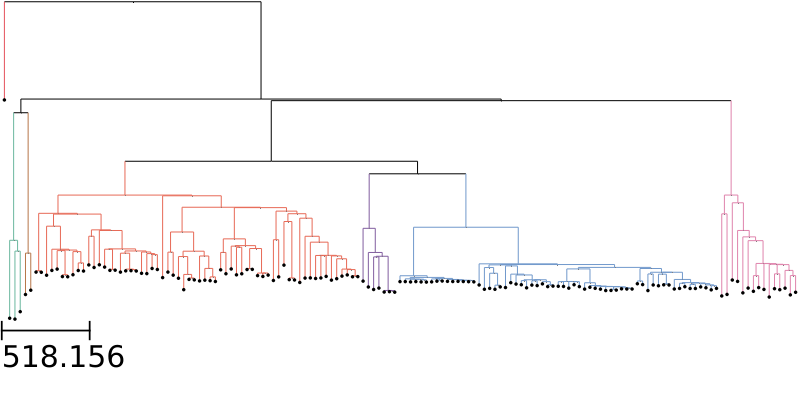

In [38]:
i_Gubbins_T.render("%%inline", w = 800, tree_style = ts_ColLin)

# Parse all detected variants (`Mtb151CI`) annotated by CDS effect

In [39]:
!ls -1 ../../Data/

220317_HRecomb_Genes_MutAnalysis
220813_MtbEpitopes
220924_Valencia_Mtb_WGS_Meta
220928_Valencia_WGS_MergePE
221017_TBPortals_LRandSR_InputDataTSVs
231002.InputAsmTSVs.TBP22.29I.Complete
231121_HybridMtbAsm_QCPass_Meta_Set3
231121_HybridMtbAsm_QCPass_Meta_Set3_AsmPolishStats_OLD
231121.InputAsmTSVs.MtbSetV3.151CI
231130_Mtb_HybridVsSR_AsmSummary_TSVs
240529.Mtb151CI.SNPdistances.V1
240529.Mtb151CI.UnqVariants.V1
241024.MutSpectraAnalysis.MUSICAL
241030.Mtb151CI.AllVariants.Anno.V1
241030.Mtb151CI.UnqVariants.Anno.V1
250522.GeneLevelMutationBurdenAnalysis
250609.AntigenMutationalBurdenAnalysis
250910.PPE18.netMHCpanII.PredictionsForRecombinantSeqs
A_WGS_RunMetadata_SRAandENA
TBP22.22CI.GCEVerfIsolates.Metadata
Tgen1K_WGS_RunMetadata
TRUST.HybridAsm.154CI.Metadata


In [40]:
!ls -1 ../../Data/241030.Mtb151CI.UnqVariants.Anno.V1

Mtb.151CI.UnqVariants.CDSAnno.V1.tsv.gz
RvGenes.Mtb151CI.VariantEffectSummary.V1.tsv.gz


In [41]:
Mtb151_AllVar_Dir = "../../Data/241030.Mtb151CI.AllVariants.Anno.V1"

Mtb151_AllVar_TSVGZ              = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.V1.tsv.gz"
Mtb151_AllVar_WiCDSAnno_TSVGZ    = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.WiCDSAnno.V1.tsv.gz"
Mtb151_SNPs_WiInterSNPDist_TSVGZ =  f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllSNPs.WiInterSNPDists.V1.tsv"

MRS_151CI_VarAnno_DF = pd.read_csv(Mtb151_AllVar_WiCDSAnno_TSVGZ, sep="\t")

MRS_151CI_VarAnno_DF.shape


(260869, 20)

In [42]:
MRS_151CI_VarAnno_DF['Alt_WithStopCodon'].value_counts()

Alt_WithStopCodon
_        136955
False    122169
True       1745
Name: count, dtype: int64

In [43]:
MRS_151CI_VarAnno_DF['SNP'].value_counts()

SNP
True     220430
False     40439
Name: count, dtype: int64

In [44]:
# WGA151_AllVar_DF = MRS_151CI_VarAnno_DF
# WGA151_AllVar_DF.shape

## Divide annotated variants by their predicted effect (Round 2)

In [45]:

Var_SNPs_Syn_DF = MRS_151CI_VarAnno_DF.query("Variant_Group == 'Synonymous_SNP' ")
print("Synonymous SNPs:", Var_SNPs_Syn_DF.shape)

Var_SNPs_NS_DF =  MRS_151CI_VarAnno_DF.query("Variant_Group == 'Missensse_SNP' ")
print("Missense SNPs:", Var_SNPs_NS_DF.shape)

Var_SNPs_NS_WiSTOP_DF =  MRS_151CI_VarAnno_DF.query("Variant_Group == 'PrematureStop_SNP' ")
print("Nonsense (premature stop): ", Var_SNPs_NS_WiSTOP_DF.shape)

Var_INDELs_Inframe_DF =  MRS_151CI_VarAnno_DF.query("Variant_Group == 'Inframe_INDEL' ")
print("INFRAME INDEL:", Var_INDELs_Inframe_DF.shape)

Var_INDELs_Frameshift_DF = MRS_151CI_VarAnno_DF.query("Variant_Group == 'Frameshift_INDEL' ")
print("FRAMESHIFT INDEL:", Var_INDELs_Frameshift_DF.shape)

Synonymous SNPs: (96849, 20)
Missense SNPs: (121836, 20)
Nonsense (premature stop):  (1745, 20)
INFRAME INDEL: (28878, 20)
FRAMESHIFT INDEL: (11561, 20)


### Look at DF of annotated variants (Across all genomes)

In [46]:
MRS_151CI_VarAnno_DF.head(3)

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
0,01_R1134,NC_000962.3,1976,1977,A,G,True,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Synonymous_SNP,_,NaN,False,Synonymous_SNP
1,01_R1134,NC_000962.3,4012,4013,T,C,True,1,recF,+,733.0,245.0,2.0,I,T,NonSynonymous_SNP,False,NaN,False,Missensse_SNP
2,01_R1134,NC_000962.3,7361,7362,G,C,True,1,gyrA,+,60.0,21.0,1.0,E,Q,NonSynonymous_SNP,False,NaN,False,Missensse_SNP


In [47]:
MRS_151CI_VarAnno_DF.query("Symbol == 'rpoB' & Codon == 450").head(4)

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
188,01_R1134,NC_000962.3,761154,761155,C,T,True,1,rpoB,+,1348.0,450.0,2.0,S,L,NonSynonymous_SNP,False,NaN,False,Missensse_SNP
1334,01_R1430,NC_000962.3,761154,761155,C,T,True,1,rpoB,+,1348.0,450.0,2.0,S,L,NonSynonymous_SNP,False,NaN,False,Missensse_SNP
2549,02_R0894,NC_000962.3,761154,761155,C,T,True,1,rpoB,+,1348.0,450.0,2.0,S,L,NonSynonymous_SNP,False,NaN,False,Missensse_SNP
3857,02_R1179,NC_000962.3,761154,761155,C,T,True,1,rpoB,+,1348.0,450.0,2.0,S,L,NonSynonymous_SNP,False,NaN,False,Missensse_SNP


In [48]:
MRS_151CI_VarAnno_DF.query("Symbol == 'rpoB' & Codon == 450").shape

(54, 20)

In [49]:
MRS_151CI_VarAnno_DF["SampleID"].nunique()

151

In [50]:
MRS_151CI_VarAnno_DF["Symbol"].nunique()

3800

In [51]:
MRS_151CI_VarAnno_DF["SNP"].value_counts()

SNP
True     220430
False     40439
Name: count, dtype: int64

In [52]:
MRS_151CI_VarAnno_DF["Variant_Type"].value_counts()

Variant_Type
NonSynonymous_SNP    123581
Synonymous_SNP        96849
INDEL                 40439
Name: count, dtype: int64

In [53]:
Var_INDELs_DF =  MRS_151CI_VarAnno_DF.query("Variant_Type == 'INDEL' ")
Var_INDELs_DF.shape

(40439, 20)

In [54]:
MRS_151CI_VarAnno_DF.query("Variant_Type == 'INDEL' ")["Symbol"].isna().sum()

10519

In [55]:
Var_INDELs_DF.head(5)

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
18,01_R1134,NC_000962.3,55553,55553,-,CGT,False,1,ponA1,+,1891.0,631.0,2.0,NaN,NaN,INDEL,_,INS,False,Inframe_INDEL
26,01_R1134,NC_000962.3,71584,71584,-,CGAGCGCTGTTCTGGCGCTAATCTGACGCTAGAATAG,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDEL,_,INS,True,Frameshift_INDEL
45,01_R1134,NC_000962.3,125830,125830,-,A,False,1,ctpI,-,4710.0,1571.0,1.0,NaN,NaN,INDEL,_,NaN,False,Inframe_INDEL
49,01_R1134,NC_000962.3,131174,131174,-,G,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDEL,_,NaN,False,Inframe_INDEL
54,01_R1134,NC_000962.3,150890,150890,-,CGGCGGGCCCGGCGGTCAGGGCGGTCAGGCGTTCGGCGCTAACAAT...,False,1,PE_PGRS2,+,1358.0,453.0,3.0,NaN,NaN,INDEL,_,INS,False,Inframe_INDEL


### Look at breakdown of variant types

In [56]:
MRS_151CI_VarAnno_DF["Variant_Type"].value_counts()

Variant_Type
NonSynonymous_SNP    123581
Synonymous_SNP        96849
INDEL                 40439
Name: count, dtype: int64

In [57]:
MRS_151CI_VarAnno_DF["Variant_Group"].value_counts()

Variant_Group
Missensse_SNP        121836
Synonymous_SNP        96849
Inframe_INDEL         28878
Frameshift_INDEL      11561
PrematureStop_SNP      1745
Name: count, dtype: int64

In [58]:
MRS_151CI_VarAnno_DF["INDEL_Type"].value_counts()

INDEL_Type
INS    15286
DEL    11316
Name: count, dtype: int64

In [59]:
MRS_151CI_VarAnno_DF[["INDEL_Type", "Variant_Group"]].value_counts()

INDEL_Type  Variant_Group   
INS         Inframe_INDEL       8811
            Frameshift_INDEL    6475
DEL         Inframe_INDEL       6230
            Frameshift_INDEL    5086
Name: count, dtype: int64

In [60]:
MRS_151CI_VarAnno_DF.head()

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
0,01_R1134,NC_000962.3,1976,1977,A,G,True,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Synonymous_SNP,_,NaN,False,Synonymous_SNP
1,01_R1134,NC_000962.3,4012,4013,T,C,True,1,recF,+,733.0,245.0,2.0,I,T,NonSynonymous_SNP,False,NaN,False,Missensse_SNP
2,01_R1134,NC_000962.3,7361,7362,G,C,True,1,gyrA,+,60.0,21.0,1.0,E,Q,NonSynonymous_SNP,False,NaN,False,Missensse_SNP
3,01_R1134,NC_000962.3,7584,7585,G,C,True,1,gyrA,+,283.0,95.0,2.0,S,T,NonSynonymous_SNP,False,NaN,False,Missensse_SNP
4,01_R1134,NC_000962.3,9303,9304,G,A,True,1,gyrA,+,2002.0,668.0,2.0,G,D,NonSynonymous_SNP,False,NaN,False,Missensse_SNP


## Calculate Gene-level summary of variant types (Across H37Rv)

In [61]:
Gene_MutSummary_DF = H37Rv_GenomeAnno_Genes_DF.copy()

Region_CoordCols = ["Chrom", "Start", "End"]
Var_CoordCols = ["Chrom", "Start_0", "End"]

PerSymbol_SNPs_Syn_Count = Var_SNPs_Syn_DF.groupby("Symbol")["SampleID"].count()
PerSymbol_SNPs_NS_Count = Var_SNPs_NS_DF.groupby("Symbol")["SampleID"].count()
PerSymbol_SNPs_NS_WiSTOP_Count = Var_SNPs_NS_WiSTOP_DF.groupby("Symbol")["SampleID"].count()
PerSymbol_INDELs_Inframe_Count = Var_INDELs_Inframe_DF.groupby("Symbol")["SampleID"].count()
PerSymbol_INDELs_Frameshift_Count = Var_INDELs_Frameshift_DF.groupby("Symbol")["SampleID"].count()

Gene_MutSummary_DF["N_SNPs_Syn"]           = Gene_MutSummary_DF["Symbol"].map(PerSymbol_SNPs_Syn_Count).fillna(0)
Gene_MutSummary_DF["N_SNPs_NonSyn"]        = Gene_MutSummary_DF["Symbol"].map(PerSymbol_SNPs_NS_Count).fillna(0)
Gene_MutSummary_DF["N_SNPs_PrematureStop"] = Gene_MutSummary_DF["Symbol"].map(PerSymbol_SNPs_NS_WiSTOP_Count).fillna(0)
Gene_MutSummary_DF["N_INDEL_Inframe"]      = Gene_MutSummary_DF["Symbol"].map(PerSymbol_INDELs_Inframe_Count).fillna(0)
Gene_MutSummary_DF["N_INDEL_Frameshift"]   = Gene_MutSummary_DF["Symbol"].map(PerSymbol_INDELs_Frameshift_Count).fillna(0)

Gene_MutSummary_DF["N_LOF_Var"]        = Gene_MutSummary_DF["N_SNPs_PrematureStop"] + Gene_MutSummary_DF["N_INDEL_Frameshift"]  
#Gene_MutSummary_DF['N_LOF_Percentile'] = Gene_MutSummary_DF['N_LOF_Var'].rank(pct=True) * 100

Gene_MutSummary_DF.shape



(4079, 19)

In [62]:
Gene_MutSummary_DF.columns

Index(['Chrom', 'Start', 'End', 'Strand', 'H37rv_GeneID', 'Symbol', 'Feature', 'Functional_Category', 'Is_Pseudogene', 'Product', 'PEandPPE_Subfamily', 'ExcludedGroup_Category', 'Gene_Cat_V2', 'N_SNPs_Syn', 'N_SNPs_NonSyn', 'N_SNPs_PrematureStop', 'N_INDEL_Inframe', 'N_INDEL_Frameshift', 'N_LOF_Var'], dtype='object')

In [63]:
GeneSummCols_V3 = ['Start', 'End', 'Strand', 'Symbol', 'H37rv_GeneID', 'Gene_Cat_V2', 'N_SNPs_Syn', 'N_SNPs_NonSyn', 'N_SNPs_PrematureStop', 'N_INDEL_Inframe', 'N_INDEL_Frameshift', 'N_LOF_Var', ]


In [64]:
Gene_MutSummary_DF[GeneSummCols_V3].head(5)

,Start,End,Strand,Symbol,H37rv_GeneID,Gene_Cat_V2,N_SNPs_Syn,N_SNPs_NonSyn,N_SNPs_PrematureStop,N_INDEL_Inframe,N_INDEL_Frameshift,N_LOF_Var
0,0,1524,+,dnaA,Rv0001,information pathways,3.0,19.0,0.0,0.0,0.0,0.0
1,2051,3260,+,dnaN,Rv0002,information pathways,27.0,4.0,0.0,0.0,0.0,0.0
2,3279,4437,+,recF,Rv0003,information pathways,8.0,164.0,0.0,0.0,0.0,0.0
3,4433,4997,+,Rv0004,Rv0004,conserved hypotheticals,1.0,5.0,0.0,0.0,0.0,0.0
4,5239,7267,+,gyrB,Rv0005,information pathways,14.0,29.0,0.0,0.0,0.0,0.0


# Quick exploration of mutation summary analysis per-gene

In [65]:
Gene_MutSummary_DF.head()

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,N_SNPs_Syn,N_SNPs_NonSyn,N_SNPs_PrematureStop,N_INDEL_Inframe,N_INDEL_Frameshift,N_LOF_Var
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways,3.0,19.0,0.0,0.0,0.0,0.0
1,NC_000962.3,2051,3260,+,Rv0002,dnaN,CDS,information pathways,No,DNA polymerase III (beta chain) DnaN (DNA nucl...,NaN,NotExcluded,information pathways,27.0,4.0,0.0,0.0,0.0,0.0
2,NC_000962.3,3279,4437,+,Rv0003,recF,CDS,information pathways,No,DNA replication and repair protein RecF (singl...,NaN,NotExcluded,information pathways,8.0,164.0,0.0,0.0,0.0,0.0
3,NC_000962.3,4433,4997,+,Rv0004,Rv0004,CDS,conserved hypotheticals,No,Conserved hypothetical protein,NaN,NotExcluded,conserved hypotheticals,1.0,5.0,0.0,0.0,0.0,0.0
4,NC_000962.3,5239,7267,+,Rv0005,gyrB,CDS,information pathways,No,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,NaN,NotExcluded,information pathways,14.0,29.0,0.0,0.0,0.0,0.0


In [66]:
Gene_MutSummary_DF.head()

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,N_SNPs_Syn,N_SNPs_NonSyn,N_SNPs_PrematureStop,N_INDEL_Inframe,N_INDEL_Frameshift,N_LOF_Var
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways,3.0,19.0,0.0,0.0,0.0,0.0
1,NC_000962.3,2051,3260,+,Rv0002,dnaN,CDS,information pathways,No,DNA polymerase III (beta chain) DnaN (DNA nucl...,NaN,NotExcluded,information pathways,27.0,4.0,0.0,0.0,0.0,0.0
2,NC_000962.3,3279,4437,+,Rv0003,recF,CDS,information pathways,No,DNA replication and repair protein RecF (singl...,NaN,NotExcluded,information pathways,8.0,164.0,0.0,0.0,0.0,0.0
3,NC_000962.3,4433,4997,+,Rv0004,Rv0004,CDS,conserved hypotheticals,No,Conserved hypothetical protein,NaN,NotExcluded,conserved hypotheticals,1.0,5.0,0.0,0.0,0.0,0.0
4,NC_000962.3,5239,7267,+,Rv0005,gyrB,CDS,information pathways,No,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,NaN,NotExcluded,information pathways,14.0,29.0,0.0,0.0,0.0,0.0


In [67]:
Gene_MutSummary_DF.shape

(4079, 19)

In [68]:
Gene_MutSummary_DF.query("N_LOF_Var >= 2").shape

(388, 19)

In [69]:
Gene_MutSummary_DF.query("N_LOF_Var > 0").shape

(692, 19)

In [70]:
Gene_MutSummary_DF.query("N_LOF_Var == 0").shape

(3387, 19)

In [71]:
Gene_MutSummary_DF.query("Symbol == 'recA'")

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,N_SNPs_Syn,N_SNPs_NonSyn,N_SNPs_PrematureStop,N_INDEL_Inframe,N_INDEL_Frameshift,N_LOF_Var
2849,NC_000962.3,3049051,3051424,-,Rv2737c,recA,CDS,information pathways,No,RecA protein (recombinase A) [contains: endonu...,NaN,NotExcluded,information pathways,5.0,12.0,0.0,0.0,0.0,0.0


In [72]:
Gene_MutSummary_DF.columns

Index(['Chrom', 'Start', 'End', 'Strand', 'H37rv_GeneID', 'Symbol', 'Feature', 'Functional_Category', 'Is_Pseudogene', 'Product', 'PEandPPE_Subfamily', 'ExcludedGroup_Category', 'Gene_Cat_V2', 'N_SNPs_Syn', 'N_SNPs_NonSyn', 'N_SNPs_PrematureStop', 'N_INDEL_Inframe', 'N_INDEL_Frameshift', 'N_LOF_Var'], dtype='object')

# Subset LOF Analysis for genes related to DNA repair pathways (N = 59)

In [73]:
DR_Genes_MutSumm_DF = Gene_MutSummary_DF[Gene_MutSummary_DF['H37rv_GeneID'].isin(DNARepair_RvIDs)].copy()
DR_Genes_MutSumm_DF['DNARepair_FunctionGroup'] = DR_Genes_MutSumm_DF['H37rv_GeneID'].map(rv_to_function_group)

DR_Genes_MutSumm_DF['Protein'] = DR_Genes_MutSumm_DF['H37rv_GeneID'].map(DNARepairGenes_Rv_to_Protein_name)

DR_Genes_MutSumm_DF = DR_Genes_MutSumm_DF.sort_values(by=['DNARepair_FunctionGroup', "Protein"] )

# Add a flag to indicate whether a gene has any LOF mutations
DR_Genes_MutSumm_DF['Has_Any_LOF'] = DR_Genes_MutSumm_DF['N_LOF_Var'] > 0
DR_Genes_MutSumm_DF['LOF_PopFreq'] = DR_Genes_MutSumm_DF['N_LOF_Var'] / 151
DR_Genes_MutSumm_DF = DR_Genes_MutSumm_DF.reset_index(drop=True)

GeneSummCols_V1 = ['DNARepair_FunctionGroup', 'H37rv_GeneID', 'Symbol', 'Protein',
                   'N_SNPs_Syn', 'N_SNPs_NonSyn', 'N_SNPs_PrematureStop', 'N_INDEL_Inframe', 'N_INDEL_Frameshift', 'N_LOF_Var', 'LOF_PopFreq',]

GeneSummCols_V2 = ['DNARepair_FunctionGroup', 'H37rv_GeneID', 'Symbol',
                   'Protein', "N_LOF_Var", 'LOF_PopFreq',
                   'N_SNPs_PrematureStop', #'N_INDEL_Inframe',
                   'N_INDEL_Frameshift']


GeneSummCols_V4 = ['DNARepair_FunctionGroup', 'H37rv_GeneID', #'Symbol',
                   'Protein', 'N_SNPs_PrematureStop', 'N_INDEL_Frameshift']

In [74]:
DR_Genes_MutSumm_DF.columns

Index(['Chrom', 'Start', 'End', 'Strand', 'H37rv_GeneID', 'Symbol', 'Feature', 'Functional_Category', 'Is_Pseudogene', 'Product', 'PEandPPE_Subfamily', 'ExcludedGroup_Category', 'Gene_Cat_V2', 'N_SNPs_Syn', 'N_SNPs_NonSyn', 'N_SNPs_PrematureStop', 'N_INDEL_Inframe', 'N_INDEL_Frameshift', 'N_LOF_Var', 'DNARepair_FunctionGroup', 'Protein', 'Has_Any_LOF', 'LOF_PopFreq'], dtype='object')

In [75]:
DR_Genes_MutSumm_DF.shape

(59, 23)

# Output mutation summary stats per gene (All H37Rv genes & just DNA Repair Genes)

In [76]:
!mkdir ../../Data250522.GeneLevelMutationBurdenAnalysis

In [77]:
GeneMutBurden_OutDir  = "../../Data/250522.GeneLevelMutationBurdenAnalysis"

!mkdir $GeneMutBurden_OutDir
Mtb151_AnnoVar_V2_TSVGZ = f"{GeneMutBurden_OutDir}/Mtb.151CI.UnqVariants.CDSAnno.V2.tsv.gz"

PerGene_MutBurdenSummary_TSV = f"{GeneMutBurden_OutDir}/250522.Mtb.PerGene.MutationBurdenSummary.V1.tsv"

PerGene_DNARepair_MutBurdenSummary_TSV = f"{GeneMutBurden_OutDir}/250522.Mtb.DNARepairGenes.MutationBurdenSummary.V1.tsv"

PerGene_DNARepair_MutBurdenSummary_Simple_TSV = f"{GeneMutBurden_OutDir}/250522.Mtb.DNARepairGenes.MutationBurdenSummary.Simple.V2.tsv"

Gene_MutSummary_DF.to_csv(PerGene_MutBurdenSummary_TSV, sep = "\t", index=False)
DR_Genes_MutSumm_DF.to_csv(PerGene_DNARepair_MutBurdenSummary_TSV, sep = "\t", index=False)

DR_Genes_MutSumm_DF[GeneSummCols_V4].to_csv(PerGene_DNARepair_MutBurdenSummary_Simple_TSV, sep = "\t", index=False)


mkdir: cannot create directory ‘../../Data/250522.GeneLevelMutationBurdenAnalysis’: File exists


In [78]:
!ls -lah $GeneMutBurden_OutDir

total 8.0M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Aug  4 18:52 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Nov 13 14:12 ..
-rw-r--r-- 1 mm774 hpc_farhat 3.1K Nov 13 15:45 250522.Mtb.DNARepairGenes.MutationBurdenSummary.Simple.V2.tsv
-rw-r--r-- 1 mm774 hpc_farhat  15K Nov 13 15:45 250522.Mtb.DNARepairGenes.MutationBurdenSummary.V1.tsv
-rw-r--r-- 1 mm774 hpc_farhat 763K Nov 13 15:45 250522.Mtb.PerGene.MutationBurdenSummary.V1.tsv
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Aug  4 18:50 .ipynb_checkpoints
-rw-r--r-- 1 mm774 hpc_farhat 7.2M Sep  9 21:07 Mtb.151CI.UnqVariants.CDSAnno.V2.tsv.gz


# Explore mutational burden and Loss-of-function in DNA Repair Genes

In [79]:
DR_Genes_MutSumm_DF["Has_Any_LOF"].value_counts()

Has_Any_LOF
False    57
True      2
Name: count, dtype: int64

In [80]:
DR_Genes_MutSumm_DF.query("N_LOF_Var > 0")

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,N_SNPs_Syn,N_SNPs_NonSyn,N_SNPs_PrematureStop,N_INDEL_Inframe,N_INDEL_Frameshift,N_LOF_Var,DNARepair_FunctionGroup,Protein,Has_Any_LOF,LOF_PopFreq
13,NC_000962.3,3425583,3427107,+,Rv3062,ligB,CDS,information pathways,No,Probable ATP-dependent DNA ligase LigB (polyde...,NaN,NotExcluded,information pathways,16.0,161.0,1.0,2.0,0.0,1.0,DNA ligases,LigB,True,0.006623
51,NC_000962.3,4026443,4027886,+,Rv3585,radA,CDS,information pathways,No,DNA repair protein RadA (DNA repair protein SMS),NaN,NotExcluded,information pathways,169.0,12.0,0.0,0.0,1.0,1.0,Other proteins,RadA,True,0.006623


In [81]:
DR_Genes_MutSumm_DF[GeneSummCols_V1].query("N_LOF_Var > 0")

,DNARepair_FunctionGroup,H37rv_GeneID,Symbol,Protein,N_SNPs_Syn,N_SNPs_NonSyn,N_SNPs_PrematureStop,N_INDEL_Inframe,N_INDEL_Frameshift,N_LOF_Var,LOF_PopFreq
13,DNA ligases,Rv3062,ligB,LigB,16.0,161.0,1.0,2.0,0.0,1.0,0.006623
51,Other proteins,Rv3585,radA,RadA,169.0,12.0,0.0,0.0,1.0,1.0,0.006623


In [82]:
DR_Genes_MutSumm_DF[GeneSummCols_V2].query("N_LOF_Var > 0")

,DNARepair_FunctionGroup,H37rv_GeneID,Symbol,Protein,N_LOF_Var,LOF_PopFreq,N_SNPs_PrematureStop,N_INDEL_Frameshift
13,DNA ligases,Rv3062,ligB,LigB,1.0,0.006623,1.0,0.0
51,Other proteins,Rv3585,radA,RadA,1.0,0.006623,0.0,1.0


#### Investigate `ligB` LoF mutation (Premature STOP by SNP) in `N1202` (L6)

In [83]:
MRS_151CI_VarAnno_DF.query("Symbol == 'ligB' & Variant_Group == 'PrematureStop_SNP' ")

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
59431,N1202,NC_000962.3,3426886,3426887,G,A,True,1,ligB,+,1303.0,435.0,2.0,W,*,NonSynonymous_SNP,True,NaN,False,PrematureStop_SNP


In [84]:
WGA151CI_AsmSummary_DF.query("SampleID == 'N1202'")

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
44,N1202,1,362,lineage6,"lineage6,lineageBOV_AFRI",ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon


#### Investigate `radA` LoF mutation (Frameshift by DELETION) in `R21770` (L4.1.1.3)

In [85]:
MRS_151CI_VarAnno_DF.query("Symbol == 'radA' & Variant_Group == 'Frameshift_INDEL' ")

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
92905,R21770,NC_000962.3,4026828,4026956,GTCAGATCCGGCTGCGTGCCGACCGGATCGGCTGCGGCACGGAGGT...,-,False,1,radA,+,385.0,129.0,2.0,NaN,NaN,INDEL,_,DEL,True,Frameshift_INDEL


In [86]:
WGA151CI_AsmSummary_DF.query("SampleID == 'R21770'")

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
115,R21770,1,113,lineage4,lineage4.1.1.3,Hall2022,ONT9.4_LR_FlyeI3M_SR_Pilon_PolyPolish


In [87]:
#DR_Genes_MutSumm_DF[GeneSummCols_V1]

In [88]:
DR_Genes_MutSumm_DF[GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
0,AP endonucleases,Rv0670,End (Nfo),0.0,0.0
1,AP endonucleases,Rv0427c,XthA,0.0,0.0
2,Base excision repair - DNA glycosylases,Rv1317c,AlkA,0.0,0.0
3,Base excision repair - DNA glycosylases,Rv0944,Fpg2,0.0,0.0
4,Base excision repair - DNA glycosylases,Rv2924c,MutM (Fpg),0.0,0.0
5,Base excision repair - DNA glycosylases,Rv3589,MutY,0.0,0.0
6,Base excision repair - DNA glycosylases,Rv2464c,Nei1,0.0,0.0
7,Base excision repair - DNA glycosylases,Rv3297,Nei2,0.0,0.0
8,Base excision repair - DNA glycosylases,Rv3674c,Nth,0.0,0.0
9,Base excision repair - DNA glycosylases,Rv1210,TagA,0.0,0.0


In [89]:
# 5 genes
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Homologous recombination: end resection and RecA loading' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
22,Homologous recombination: end resection and Re...,Rv3202c,AdnA,0.0,0.0
23,Homologous recombination: end resection and Re...,Rv3201c,AdnB,0.0,0.0
24,Homologous recombination: end resection and Re...,Rv0003,RecF,0.0,0.0
25,Homologous recombination: end resection and Re...,Rv2362c,RecO,0.0,0.0
26,Homologous recombination: end resection and Re...,Rv3715c,RecR,0.0,0.0


In [90]:
# 3 genes
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Homologous recombination: strand exchange' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
32,Homologous recombination: strand exchange,Rv2737c,RecA,0.0,0.0
33,Homologous recombination: strand exchange,Rv0054,SSBa,0.0,0.0
34,Homologous recombination: strand exchange,Rv2478c,SSBb,0.0,0.0


In [91]:
# 5 genes
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Homologous recombination: resolution' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
27,Homologous recombination: resolution,Rv2973c,RecG,0.0,0.0
28,Homologous recombination: resolution,Rv2593c,RuvA,0.0,0.0
29,Homologous recombination: resolution,Rv2592c,RuvB,0.0,0.0
30,Homologous recombination: resolution,Rv2594c,RuvC,0.0,0.0
31,Homologous recombination: resolution,Rv2554c,RuvX,0.0,0.0


In [92]:
DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"].value_counts()

DNARepair_FunctionGroup
Base excision repair - DNA glycosylases                     10
DNA polymerases                                              7
Nucleotide excision repair                                   7
Nucleotide pool sanitization enzymes                         6
Homologous recombination: resolution                         5
Homologous recombination: end resection and RecA loading     5
Other proteins                                               4
DNA ligases                                                  3
Single-strand annealing pathway                              3
Homologous recombination: strand exchange                    3
AP endonucleases                                             2
Non-homologous end joining                                   2
Mismatch repair                                              1
Ribonucleotide excision                                      1
Name: count, dtype: int64

#### Look at stats for specific subgroups of DNA Repair Genes

In [93]:
# 
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Base excision repair - DNA glycosylases' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
2,Base excision repair - DNA glycosylases,Rv1317c,AlkA,0.0,0.0
3,Base excision repair - DNA glycosylases,Rv0944,Fpg2,0.0,0.0
4,Base excision repair - DNA glycosylases,Rv2924c,MutM (Fpg),0.0,0.0
5,Base excision repair - DNA glycosylases,Rv3589,MutY,0.0,0.0
6,Base excision repair - DNA glycosylases,Rv2464c,Nei1,0.0,0.0
7,Base excision repair - DNA glycosylases,Rv3297,Nei2,0.0,0.0
8,Base excision repair - DNA glycosylases,Rv3674c,Nth,0.0,0.0
9,Base excision repair - DNA glycosylases,Rv1210,TagA,0.0,0.0
10,Base excision repair - DNA glycosylases,Rv1259,UdgB,0.0,0.0
11,Base excision repair - DNA glycosylases,Rv2976c,Ung,0.0,0.0


In [94]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'DNA polymerases' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
15,DNA polymerases,Rv1537,DinB1,0.0,0.0
16,DNA polymerases,Rv3056,DinB2,0.0,0.0
17,DNA polymerases,Rv1547,DnaE1,0.0,0.0
18,DNA polymerases,Rv3370c,DnaE2,0.0,0.0
19,DNA polymerases,Rv1629,PolA,0.0,0.0
20,DNA polymerases,Rv3730c,PolD1/Prim-PolC,0.0,0.0
21,DNA polymerases,Rv0269c,PolD2,0.0,0.0


In [95]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Nucleotide excision repair' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
38,Nucleotide excision repair,Rv2191,Cho,0.0,0.0
39,Nucleotide excision repair,Rv1020,Mfd,0.0,0.0
40,Nucleotide excision repair,Rv1638,UvrA,0.0,0.0
41,Nucleotide excision repair,Rv1633,UvrB,0.0,0.0
42,Nucleotide excision repair,Rv1420,UvrC,0.0,0.0
43,Nucleotide excision repair,Rv0949,UvrD1,0.0,0.0
44,Nucleotide excision repair,Rv3198c,UvrD2,0.0,0.0


In [96]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Nucleotide pool sanitization enzymes' ][GeneSummCols_V2]

,DNARepair_FunctionGroup,H37rv_GeneID,Symbol,Protein,N_LOF_Var,LOF_PopFreq,N_SNPs_PrematureStop,N_INDEL_Frameshift
45,Nucleotide pool sanitization enzymes,Rv2697c,dut,Dut,0.0,0.0,0.0,0.0
46,Nucleotide pool sanitization enzymes,Rv1021,Rv1021,MazG,0.0,0.0,0.0,0.0
47,Nucleotide pool sanitization enzymes,Rv2985,mutT1,MutT1,0.0,0.0,0.0,0.0
48,Nucleotide pool sanitization enzymes,Rv1160,mutT2,MutT2,0.0,0.0,0.0,0.0
49,Nucleotide pool sanitization enzymes,Rv0413,mutT3,MutT3,0.0,0.0,0.0,0.0
50,Nucleotide pool sanitization enzymes,Rv3908,mutT4,MutT4,0.0,0.0,0.0,0.0


In [97]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'DNA ligases' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
12,DNA ligases,Rv3104c,LigA,0.0,0.0
13,DNA ligases,Rv3062,LigB,1.0,0.0
14,DNA ligases,Rv3731,LigC,0.0,0.0


In [98]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Single-strand annealing pathway' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
56,Single-strand annealing pathway,Rv0630c,RecB,0.0,0.0
57,Single-strand annealing pathway,Rv0631c,RecC,0.0,0.0
58,Single-strand annealing pathway,Rv0629c,RecD,0.0,0.0


In [99]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'AP endonucleases' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
0,AP endonucleases,Rv0670,End (Nfo),0.0,0.0
1,AP endonucleases,Rv0427c,XthA,0.0,0.0


In [100]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Non-homologous end joining' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
36,Non-homologous end joining,Rv0937c,Ku,0.0,0.0
37,Non-homologous end joining,Rv0938,LigD,0.0,0.0


In [101]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Mismatch repair' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
35,Mismatch repair,Rv1321,NucS,0.0,0.0


In [102]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Ribonucleotide excision' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
55,Ribonucleotide excision,Rv2228c,RNaseH1,0.0,0.0


In [103]:
DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == 'Other proteins' ][GeneSummCols_V4]

,DNARepair_FunctionGroup,H37rv_GeneID,Protein,N_SNPs_PrematureStop,N_INDEL_Frameshift
51,Other proteins,Rv3585,RadA,0.0,1.0
52,Other proteins,Rv2694c,RecG,0.0,0.0
53,Other proteins,Rv1696,RecN,0.0,0.0
54,Other proteins,Rv2736c,RecX,0.0,0.0


In [104]:
#DR_Genes_MutSumm_DF[DR_Genes_MutSumm_DF["DNARepair_FunctionGroup"] == '____' ][GeneSummCols_V2]

### Visualize LoF Frequency across different DNA Repair Genes Groups

In [105]:
DR_Genes_MutSumm_DF.columns

Index(['Chrom', 'Start', 'End', 'Strand', 'H37rv_GeneID', 'Symbol', 'Feature', 'Functional_Category', 'Is_Pseudogene', 'Product', 'PEandPPE_Subfamily', 'ExcludedGroup_Category', 'Gene_Cat_V2', 'N_SNPs_Syn', 'N_SNPs_NonSyn', 'N_SNPs_PrematureStop', 'N_INDEL_Inframe', 'N_INDEL_Frameshift', 'N_LOF_Var', 'DNARepair_FunctionGroup', 'Protein', 'Has_Any_LOF', 'LOF_PopFreq'], dtype='object')

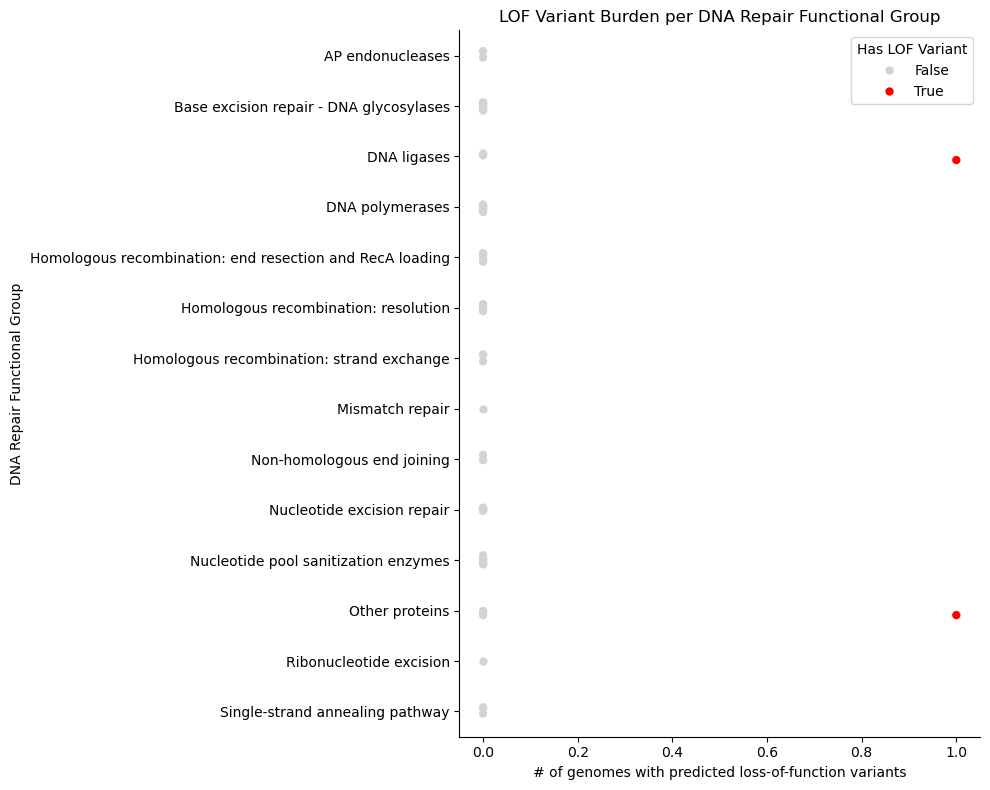

In [106]:

# Plot with customized colors: red for LOF genes, grey otherwise
plt.figure(figsize=(10, 8))
sns.stripplot( data=DR_Genes_MutSumm_DF,
    y='DNARepair_FunctionGroup',
    x='N_LOF_Var',
    hue='Has_Any_LOF',
    palette={True: 'red', False: 'lightgray'},
    jitter=True,
    marker='o',
    size=6
)

# Adjust aesthetics
plt.ylabel('DNA Repair Functional Group')
plt.xlabel('# of genomes with predicted loss-of-function variants')
plt.title('LOF Variant Burden per DNA Repair Functional Group')
plt.legend(title='Has LOF Variant', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()


# Label isolates w/ LoF variants on phylogeny

In [107]:
DR_Genes_MutSumm_DF[GeneSummCols_V2].query("N_LOF_Var > 0")

,DNARepair_FunctionGroup,H37rv_GeneID,Symbol,Protein,N_LOF_Var,LOF_PopFreq,N_SNPs_PrematureStop,N_INDEL_Frameshift
13,DNA ligases,Rv3062,ligB,LigB,1.0,0.006623,1.0,0.0
51,Other proteins,Rv3585,radA,RadA,1.0,0.006623,0.0,1.0


In [108]:
MRS_151CI_VarAnno_DF.query("Symbol == 'ligB' & Variant_Group == 'PrematureStop_SNP' ")

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
59431,N1202,NC_000962.3,3426886,3426887,G,A,True,1,ligB,+,1303.0,435.0,2.0,W,*,NonSynonymous_SNP,True,NaN,False,PrematureStop_SNP


In [109]:
MRS_151CI_VarAnno_DF.query("Symbol == 'radA' & Variant_Group == 'Frameshift_INDEL' ")

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
92905,R21770,NC_000962.3,4026828,4026956,GTCAGATCCGGCTGCGTGCCGACCGGATCGGCTGCGGCACGGAGGT...,-,False,1,radA,+,385.0,129.0,2.0,NaN,NaN,INDEL,_,DEL,True,Frameshift_INDEL


In [110]:

# Tree_LinAncNodes_Labeled_1 = highlight_TargetNodes_V1(["N1202", "R21770"], i_Gubbins_T) 
# Tree_LinAncNodes_Labeled_1.render("%%inline", w = 1200, tree_style = ts_4_NoScale)


In [111]:

# Tree_LinAncNodes_Labeled_2 = highlight_TargetNodes_V1(["N1202", "R21770"], i_Gubbins_T) 
# Tree_LinAncNodes_Labeled_2.render("%%inline", w = 1200, tree_style = ts_4_FullCirc)


N1202 found. We will style this node differently.
R21770 found. We will style this node differently.


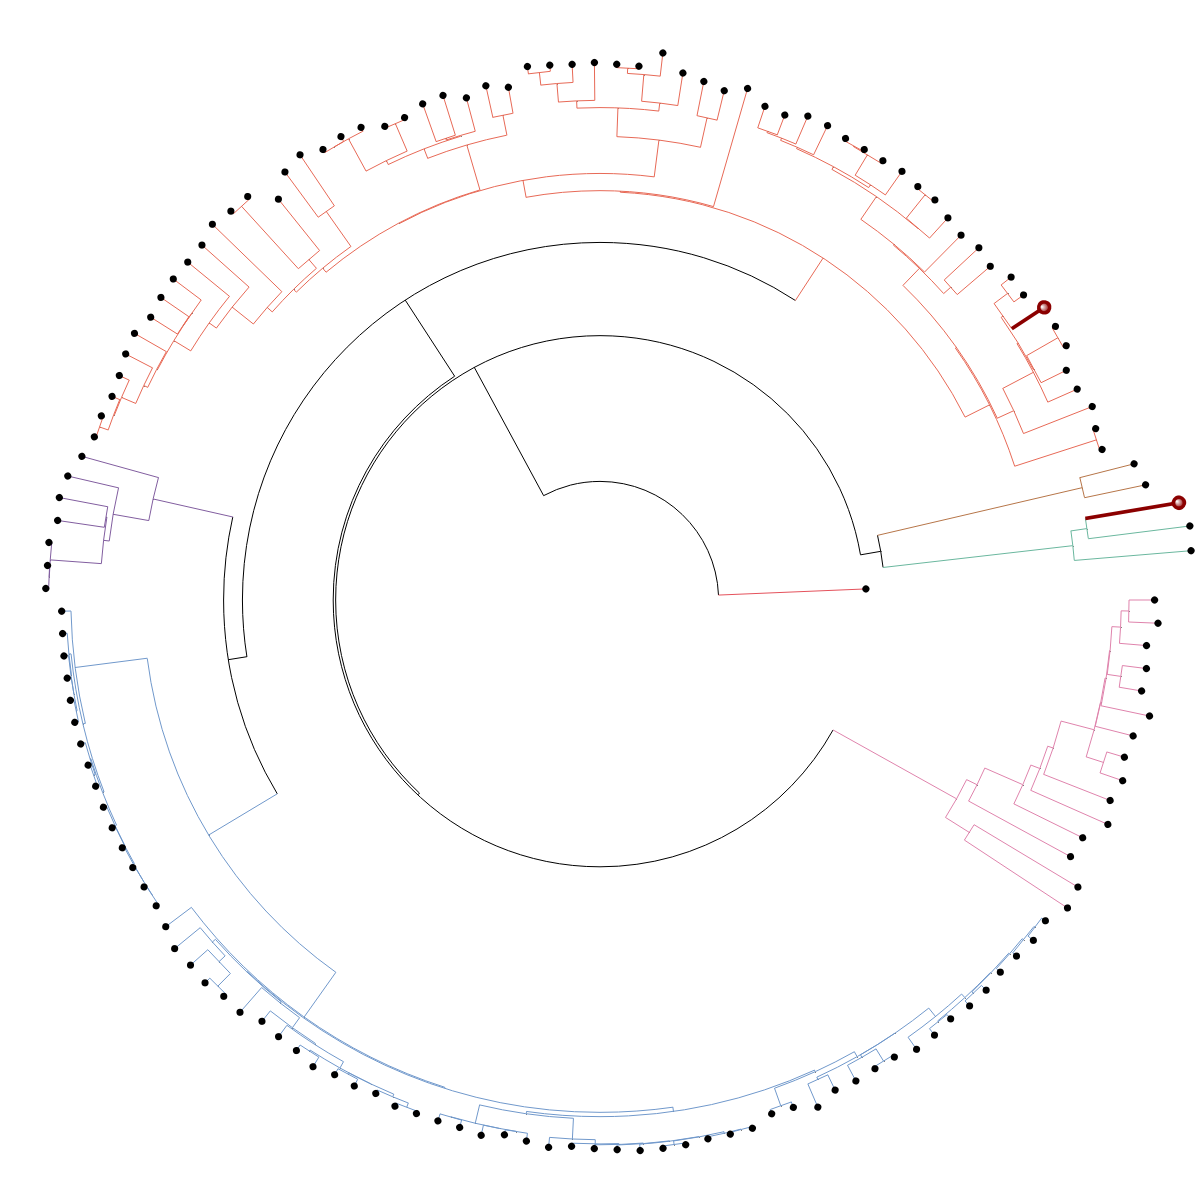

In [112]:

Tree_LinAncNodes_Labeled_3 = highlight_TargetNodes_V2(["N1202", "R21770"], i_Gubbins_T) 
Tree_LinAncNodes_Labeled_3.render("%%inline", w = 1200, tree_style = ts_4_FullCirc)


N1202 found. We will style this node differently.
R21770 found. We will style this node differently.


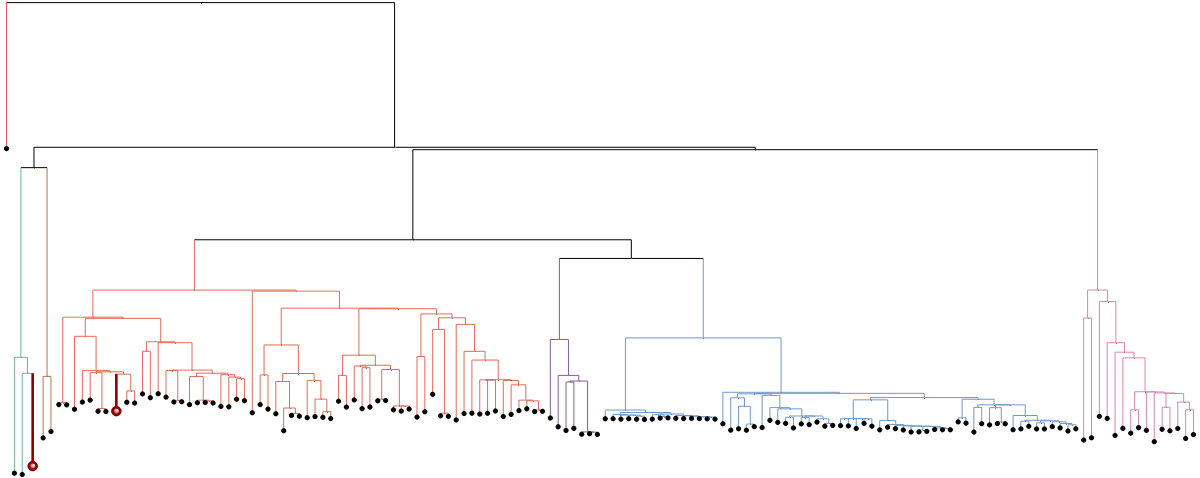

In [113]:

Tree_LinAncNodes_Labeled_3 = highlight_TargetNodes_V2(["N1202", "R21770"], i_Gubbins_T) 
Tree_LinAncNodes_Labeled_3.render("%%inline", w = 1200, tree_style = ts_4_NoScale)


# Viz LoF mutations in two DNA repair proteins

In [114]:
!mkdir ./DNARepairGenes_LoF_VarViz

## a) Viz  `N1202` (L6 Isolate) w/ LoF mutation in `ligB` (`Rv3062`)

In [115]:
WGA151CI_AsmSummary_DF.query("SampleID == 'N1202'")

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
44,N1202,1,362,lineage6,"lineage6,lineageBOV_AFRI",ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon


In [116]:
MRS_151CI_VarAnno_DF.query("Symbol == 'ligB' & Variant_Group == 'PrematureStop_SNP' ")

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
59431,N1202,NC_000962.3,3426886,3426887,G,A,True,1,ligB,+,1303.0,435.0,2.0,W,*,NonSynonymous_SNP,True,NaN,False,PrematureStop_SNP


In [117]:
# ligB (Rv3062)
dictOf_H37Rv_MycoBrow_ProtSeq["Rv3062"][434]

'W'

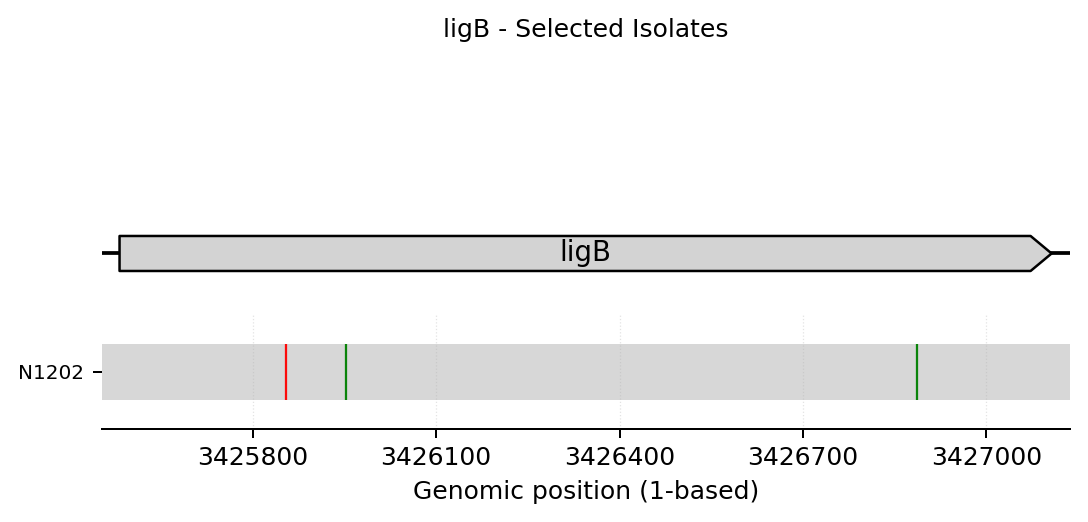

In [118]:
i_IsolatesToPlot = ["N1202"]

i_Symbol = "ligB"

i_Gene_MutInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")

i_Gene_Start = i_Gene_MutInfo_DF["Start"].values[0]
i_Gene_End = i_Gene_MutInfo_DF["End"].values[0]

Viz_Start, Viz_End =  i_Gene_Start - 30 , i_Gene_End + 30


# 1) Make the two-panel canvas with annotations on top
fig, axes = plot_Anno_with_empty_bottom(Viz_Start = Viz_Start,
                                        Viz_End   = Viz_End,
                                        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                        figsize = (6, 3),
                                        height_ratios = (4, 2),
                                        top_title = f"{i_Symbol} - Selected Isolates")

# 2) Prepare variants for the same window (your big DF -> windowed)
var_in_win = prepare_variants_window(MRS_151CI_VarAnno_DF,
                               start1 = Viz_Start,
                               end1 = Viz_End)

# 3) Draw variants onto the *bottom* axis
_, _, i_summ = plot_variants_for_isolates_simple(var_in_win,
                                            i_IsolatesToPlot,
                                            Viz_Start,
                                            Viz_End,
                                            ax=axes["Bottom_ax"],
                                            show_labels=True,
                                            bar_height = 0.8,
                                            snp_tick_height_factor=1.0,
                                            snp_line_width=0.9 ) 


fig.savefig(f"./DNARepairGenes_LoF_VarViz/{i_Symbol}.VizVariantCalls.LoF.N1202.V1.svg")
fig.savefig(f"./DNARepairGenes_LoF_VarViz/{i_Symbol}.VizVariantCalls.LoF.N1202.V1.png")
 
plt.show()


## b) Viz  `R21770` (L4 Isolate) w/ LoF mutation in `radA` (`Rv3585`)

In [119]:
WGA151CI_AsmSummary_DF.query("SampleID == 'R21770'")

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
115,R21770,1,113,lineage4,lineage4.1.1.3,Hall2022,ONT9.4_LR_FlyeI3M_SR_Pilon_PolyPolish


In [121]:
MRS_151CI_VarAnno_DF.query("Symbol == 'radA' & Variant_Group == 'Frameshift_INDEL' ")

,SampleID,Chrom,Start_0,End,Ref,Alt,SNP,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Variant_Type,Alt_WithStopCodon,INDEL_Type,frameshift,Variant_Group
92905,R21770,NC_000962.3,4026828,4026956,GTCAGATCCGGCTGCGTGCCGACCGGATCGGCTGCGGCACGGAGGT...,-,False,1,radA,+,385.0,129.0,2.0,NaN,NaN,INDEL,_,DEL,True,Frameshift_INDEL


In [122]:
# radA (Rv3585)
dictOf_H37Rv_MycoBrow_ProtSeq["Rv3585"][129]

'Q'

In [123]:
# (p.Gln129fs)

In [127]:
str(MRS_151CI_VarAnno_DF.query("Symbol == 'radA' & Variant_Group == 'Frameshift_INDEL' ")["Ref"].values[0])

'GTCAGATCCGGCTGCGTGCCGACCGGATCGGCTGCGGCACGGAGGTCGAGGAGATCTACCTCGCCGCACAGTCCGACGTGCACACCGTGCTCGACCAGATCGAGACGGTGCAGCCGGCACTGGTCATC'

In [128]:
len(str(MRS_151CI_VarAnno_DF.query("Symbol == 'radA' & Variant_Group == 'Frameshift_INDEL' ")["Ref"].values[0]))

128

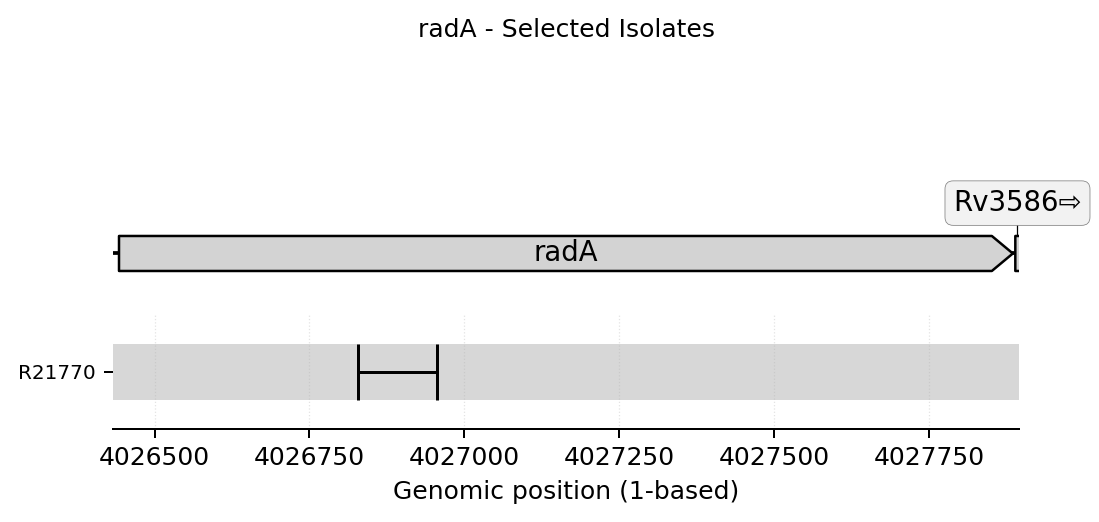

In [129]:
i_IsolatesToPlot = ["R21770"]

i_Symbol = "radA"

i_Gene_MutInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")

i_Gene_Start = i_Gene_MutInfo_DF["Start"].values[0]
i_Gene_End = i_Gene_MutInfo_DF["End"].values[0]

Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10


# 1) Make the two-panel canvas with annotations on top
fig, axes = plot_Anno_with_empty_bottom(Viz_Start = Viz_Start,
                                        Viz_End   = Viz_End,
                                        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                        figsize = (6, 3),
                                        height_ratios = (4, 2),
                                        top_title = f"{i_Symbol} - Selected Isolates")

# 2) Prepare variants for the same window (your big DF -> windowed)
var_in_win = prepare_variants_window(MRS_151CI_VarAnno_DF,
                               start1 = Viz_Start,
                               end1 = Viz_End)

# 3) Draw variants onto the *bottom* axis
_, _, i_summ = plot_variants_for_isolates_simple(var_in_win,
                                            i_IsolatesToPlot,
                                            Viz_Start,
                                            Viz_End,
                                            ax=axes["Bottom_ax"],
                                            show_labels=True,
                                            bar_height = 0.8,
                                            snp_tick_height_factor=1.0,
                                            snp_line_width=0.9 ) 


fig.savefig(f"./DNARepairGenes_LoF_VarViz/{i_Symbol}.VizVariantCalls.LoF.R21770.V1.svg")
fig.savefig(f"./DNARepairGenes_LoF_VarViz/{i_Symbol}.VizVariantCalls.LoF.R21770.V1.png")
 
plt.show()


In [130]:
DR_Genes_MutSumm_DF.shape

(59, 23)

# Extra Analysis

## Extra Exploration of DNA Repair Gene Mutation Burden Stats

In [131]:
DR_Genes_MutSumm_DF[GeneSummCols_V2]

,DNARepair_FunctionGroup,H37rv_GeneID,Symbol,Protein,N_LOF_Var,LOF_PopFreq,N_SNPs_PrematureStop,N_INDEL_Frameshift
0,AP endonucleases,Rv0670,end,End (Nfo),0.0,0.000000,0.0,0.0
1,AP endonucleases,Rv0427c,xthA,XthA,0.0,0.000000,0.0,0.0
2,Base excision repair - DNA glycosylases,Rv1317c,alkA,AlkA,0.0,0.000000,0.0,0.0
3,Base excision repair - DNA glycosylases,Rv0944,Rv0944,Fpg2,0.0,0.000000,0.0,0.0
4,Base excision repair - DNA glycosylases,Rv2924c,fpg,MutM (Fpg),0.0,0.000000,0.0,0.0
5,Base excision repair - DNA glycosylases,Rv3589,mutY,MutY,0.0,0.000000,0.0,0.0
6,Base excision repair - DNA glycosylases,Rv2464c,Rv2464c,Nei1,0.0,0.000000,0.0,0.0
7,Base excision repair - DNA glycosylases,Rv3297,nei,Nei2,0.0,0.000000,0.0,0.0
8,Base excision repair - DNA glycosylases,Rv3674c,nth,Nth,0.0,0.000000,0.0,0.0
9,Base excision repair - DNA glycosylases,Rv1210,tagA,TagA,0.0,0.000000,0.0,0.0


In [132]:
DR_Genes_MutSumm_DF.shape

(59, 23)

In [133]:
DR_Genes_MutSumm_DF.head()

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,N_SNPs_Syn,N_SNPs_NonSyn,N_SNPs_PrematureStop,N_INDEL_Inframe,N_INDEL_Frameshift,N_LOF_Var,DNARepair_FunctionGroup,Protein,Has_Any_LOF,LOF_PopFreq
0,NC_000962.3,769791,770550,+,Rv0670,end,CDS,information pathways,No,Probable endonuclease IV End (endodeoxyribonuc...,NaN,NotExcluded,information pathways,0.0,3.0,0.0,7.0,0.0,0.0,AP endonucleases,End (Nfo),False,0.0
1,NC_000962.3,516016,516892,-,Rv0427c,xthA,CDS,information pathways,No,Probable exodeoxyribonuclease III protein XthA...,NaN,NotExcluded,information pathways,2.0,2.0,0.0,1.0,0.0,0.0,AP endonucleases,XthA,False,0.0
2,NC_000962.3,1477627,1479118,-,Rv1317c,alkA,CDS,information pathways,No,Probable bifunctional regulatory protein and D...,NaN,NotExcluded,information pathways,8.0,103.0,0.0,0.0,0.0,0.0,Base excision repair - DNA glycosylases,AlkA,False,0.0
3,NC_000962.3,1053764,1054241,+,Rv0944,Rv0944,CDS,information pathways,No,Possible formamidopyrimidine-DNA glycosylase (...,NaN,NotExcluded,information pathways,3.0,16.0,0.0,0.0,0.0,0.0,Base excision repair - DNA glycosylases,Fpg2,False,0.0
4,NC_000962.3,3238600,3239470,-,Rv2924c,fpg,CDS,information pathways,No,Probable formamidopyrimidine-DNA glycosylase F...,NaN,NotExcluded,information pathways,2.0,5.0,0.0,0.0,0.0,0.0,Base excision repair - DNA glycosylases,MutM (Fpg),False,0.0


In [134]:
DR_Genes_MutSumm_DF.head()

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,N_SNPs_Syn,N_SNPs_NonSyn,N_SNPs_PrematureStop,N_INDEL_Inframe,N_INDEL_Frameshift,N_LOF_Var,DNARepair_FunctionGroup,Protein,Has_Any_LOF,LOF_PopFreq
0,NC_000962.3,769791,770550,+,Rv0670,end,CDS,information pathways,No,Probable endonuclease IV End (endodeoxyribonuc...,NaN,NotExcluded,information pathways,0.0,3.0,0.0,7.0,0.0,0.0,AP endonucleases,End (Nfo),False,0.0
1,NC_000962.3,516016,516892,-,Rv0427c,xthA,CDS,information pathways,No,Probable exodeoxyribonuclease III protein XthA...,NaN,NotExcluded,information pathways,2.0,2.0,0.0,1.0,0.0,0.0,AP endonucleases,XthA,False,0.0
2,NC_000962.3,1477627,1479118,-,Rv1317c,alkA,CDS,information pathways,No,Probable bifunctional regulatory protein and D...,NaN,NotExcluded,information pathways,8.0,103.0,0.0,0.0,0.0,0.0,Base excision repair - DNA glycosylases,AlkA,False,0.0
3,NC_000962.3,1053764,1054241,+,Rv0944,Rv0944,CDS,information pathways,No,Possible formamidopyrimidine-DNA glycosylase (...,NaN,NotExcluded,information pathways,3.0,16.0,0.0,0.0,0.0,0.0,Base excision repair - DNA glycosylases,Fpg2,False,0.0
4,NC_000962.3,3238600,3239470,-,Rv2924c,fpg,CDS,information pathways,No,Probable formamidopyrimidine-DNA glycosylase F...,NaN,NotExcluded,information pathways,2.0,5.0,0.0,0.0,0.0,0.0,Base excision repair - DNA glycosylases,MutM (Fpg),False,0.0


In [ ]:
MRS_151CI_VarAnno_V2_DF.head(1)

In [ ]:
MRS_151CI_VarAnno_V2_DF["Codon_Pos"].value_counts()

In [ ]:
MRS_151CI_VarAnno_V2_DF.query("Symbol == 'dnaN' & Variant_Group == 'PrematureStop_SNP' ")

In [ ]:
DR_Genes_MutSumm_DF[GeneSummCols_V2].query("N_LOF_Var > 0")

In [ ]:
MRS_151CI_VarAnno_V2_DF.query("Symbol == 'ligB' & Variant_Group == 'PrematureStop_SNP' ")

In [ ]:
MRS_151CI_VarAnno_V2_DF.query("Symbol == 'radA' & Variant_Group == 'Frameshift_INDEL' ")

In [ ]:
radA_FS_DEL_RefSeq = MRS_151CI_VarAnno_V2_DF.query("Symbol == 'radA' & Variant_Group == 'Frameshift_INDEL' ")["Ref"].values[0]
radA_FS_DEL_RefSeq

In [ ]:
len(radA_FS_DEL_RefSeq)